# Обучение нейросети CreditNet и сравнение моделей

In [1]:
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)

sys.path.append(str(Path('..').resolve()))
from src.model import CreditTrainer

## 1. Загрузка данных

In [2]:
processed = Path('..') / 'data' / 'processed'
X_train = np.load(processed / 'X_train.npy')
X_test = np.load(processed / 'X_test.npy')
y_train = np.load(processed / 'y_train.npy')
y_test = np.load(processed / 'y_test.npy')

print(X_train.shape, X_test.shape)

(800, 34) (200, 34)


## 2. Обучение CreditNet

In [3]:
trainer = CreditTrainer(input_dim=X_train.shape[1])
t0 = time.perf_counter()
history = trainer.train(X_train, y_train, epochs=100, lr=0.001)
mlp_time = time.perf_counter() - t0

p_mlp = trainer.predict_proba(X_test)
trainer.save(processed / 'model.pt')

print(f"Model saved: {processed / 'model.pt'}")
print(f'Train time: {mlp_time:.2f} sec')

Эпоха 001: train_loss=0.9636 val_loss=0.9374


Эпоха 010: train_loss=0.6232 val_loss=0.9500


Early stopping на эпохе 18
Model saved: ..\data\processed\model.pt
Train time: 3.88 sec


Вывод: модель обучена и сохранена для последующих SHAP-объяснений и Streamlit-демо.

## 3. График train/val loss

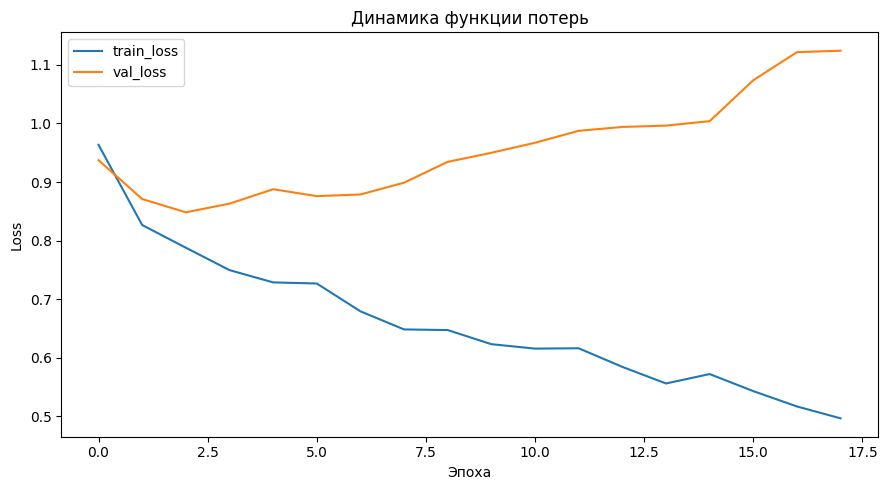

In [4]:
plt.figure(figsize=(9, 5))
plt.plot(history['train_loss'], label='train_loss')
plt.plot(history['val_loss'], label='val_loss')
plt.title('Динамика функции потерь')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Метрики MLP

In [5]:
def metric_bundle(y_true, prob, thr=0.5):
    pred = (prob >= thr).astype(int)
    return {
        'ROC-AUC': roc_auc_score(y_true, prob),
        'PR-AUC': average_precision_score(y_true, prob),
        'F1': f1_score(y_true, pred),
        'Precision': precision_score(y_true, pred, zero_division=0),
        'Recall': recall_score(y_true, pred, zero_division=0),
    }

mlp_metrics = metric_bundle(y_test, p_mlp, 0.5)
mlp_metrics

{'ROC-AUC': 0.8160714285714287,
 'PR-AUC': 0.6593922977353004,
 'F1': 0.6540880503144654,
 'Precision': 0.5252525252525253,
 'Recall': 0.8666666666666667}

Вывод: метрики показывают качество модели в разных аспектах, особенно важно смотреть PR-AUC при дисбалансе классов.

## 5. Таблица сравнения трех моделей

In [6]:
baseline_path = Path('02_baseline_metrics.json')
if baseline_path.exists():
    baseline = json.loads(baseline_path.read_text(encoding='utf-8'))
else:
    baseline = {
        'LogReg': {'ROC-AUC': np.nan, 'PR-AUC': np.nan, 'F1': np.nan, 'Время обучения': np.nan},
        'XGBoost': {'ROC-AUC': np.nan, 'PR-AUC': np.nan, 'F1': np.nan, 'Время обучения': np.nan},
    }

compare = pd.DataFrame([
    {'Модель': 'LogReg', **baseline.get('LogReg', {})},
    {'Модель': 'XGBoost', **baseline.get('XGBoost', {})},
    {
        'Модель': 'MLP (CreditNet)',
        'ROC-AUC': mlp_metrics['ROC-AUC'],
        'PR-AUC': mlp_metrics['PR-AUC'],
        'F1': mlp_metrics['F1'],
        'Время обучения': mlp_time,
    },
])
compare

,Модель,ROC-AUC,PR-AUC,F1,Время обучения
0,LogReg,NaN,NaN,NaN,NaN
1,XGBoost,NaN,NaN,NaN,NaN
2,MLP (CreditNet),0.816071,0.659392,0.654088,3.877708


## 6. Подбор оптимального порога

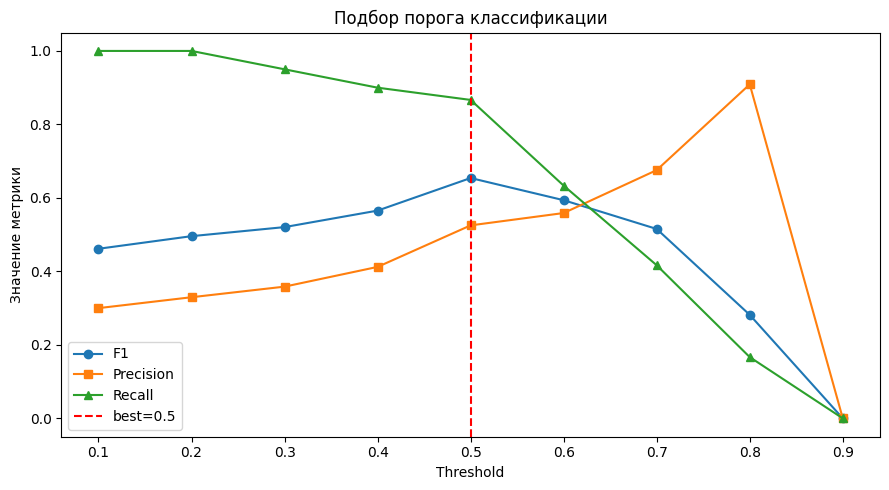

,threshold,f1,precision,recall
0,0.1,0.461538,0.300000,1.000000
1,0.2,0.495868,0.329670,1.000000
2,0.3,0.520548,0.358491,0.950000
3,0.4,0.565445,0.412214,0.900000
4,0.5,0.654088,0.525253,0.866667
5,0.6,0.593750,0.558824,0.633333
6,0.7,0.515464,0.675676,0.416667
7,0.8,0.281690,0.909091,0.166667
8,0.9,0.000000,0.000000,0.000000


In [7]:
thresholds = np.arange(0.1, 1.0, 0.1)
rows = []
for t in thresholds:
    pred = (p_mlp >= t).astype(int)
    rows.append({
        'threshold': t,
        'f1': f1_score(y_test, pred),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall': recall_score(y_test, pred, zero_division=0),
    })
thr_df = pd.DataFrame(rows)
best_thr = float(thr_df.sort_values('f1', ascending=False).iloc[0]['threshold'])

plt.figure(figsize=(9, 5))
plt.plot(thr_df['threshold'], thr_df['f1'], marker='o', label='F1')
plt.plot(thr_df['threshold'], thr_df['precision'], marker='s', label='Precision')
plt.plot(thr_df['threshold'], thr_df['recall'], marker='^', label='Recall')
plt.axvline(best_thr, color='red', linestyle='--', label=f'best={best_thr:.1f}')
plt.title('Подбор порога классификации')
plt.xlabel('Threshold')
plt.ylabel('Значение метрики')
plt.legend()
plt.tight_layout()
plt.show()

thr_df

Вывод: оптимальный порог выбирается по целевой бизнес-метрике; часто F1 дает сбалансированное решение.

## 7. Confusion matrix для оптимального порога

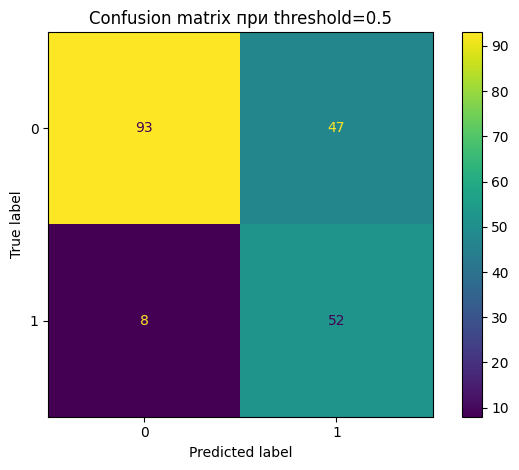

In [8]:
best_pred = (p_mlp >= best_thr).astype(int)
ConfusionMatrixDisplay.from_predictions(y_test, best_pred)
plt.title(f'Confusion matrix при threshold={best_thr:.1f}')
plt.tight_layout()
plt.show()

Заключение: нейросеть может быть лучше или хуже baseline в зависимости от настройки порога и целевой функции бизнеса. Для продакшн-решения разумно фиксировать порог с учетом стоимости ошибок I и II рода.